# Let's see how an CSV looks like

In [6]:
%%bash
mkdir -p data
curl -s https://wagon-public-datasets.s3.amazonaws.com/02-Data-Toolkit/02-Data-Sourcing/co2_sample.csv > data/co2_sample.csv
head -n 5 data/co2_sample.csv

country,2014,2015,2016,2017,2018,2019,2020,2021,2022
Afghanistan,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
Angola,1.64,1.22,1.18,1.15,1.12,1.15,1.12,1.2,1.23
Albania,2.25,2.04,2.01,2.13,2.08,2.05,2.0,2.12,2.1
Andorra,5.83,5.97,6.07,6.27,6.12,6.06,5.63,5.97,5.91


# How to load a CSV into a pandas DF

In [7]:
import pandas as pd

emissions_df = pd.read_csv("data/co2_pcap_cons.csv")
emissions_df

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.28,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,Angola,0.009,0.009,0.009,0.009,0.009,0.009,0.010,0.010,0.010,...,1.28,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230
2,Albania,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,2.27,2.250,2.040,2.010,2.130,2.080,2.050,2.000,2.120,2.100
3,Andorra,0.333,0.335,0.337,0.340,0.342,0.345,0.347,0.350,0.352,...,5.9,5.830,5.970,6.070,6.270,6.120,6.060,5.630,5.970,5.910
4,UAE,0.063,0.063,0.064,0.064,0.064,0.064,0.065,0.065,0.065,...,27,26.800,27.000,26.700,23.900,23.500,21.200,19.700,20.700,21.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,Samoa,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,1.04,1.090,1.210,1.260,1.290,1.320,1.370,1.310,1.400,1.430
190,Yemen,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.994,0.937,0.480,0.377,0.363,0.356,0.365,0.362,0.387,0.395
191,South Africa,0.003,0.003,0.004,0.004,0.004,0.004,0.004,0.004,0.004,...,6.2,6.100,5.760,5.680,5.550,5.420,5.680,5.110,5.080,5.180
192,Zambia,0.255,0.256,0.257,0.258,0.259,0.260,0.261,0.262,0.263,...,0.511,0.560,0.519,0.471,0.474,0.467,0.487,0.388,0.416,0.424


# Download the country code and the name reference table

In [8]:
!curl -s https://wagon-public-datasets.s3.amazonaws.com/02-Data-Toolkit/02-Data-Sourcing/iso2_with_region.csv > data/iso2_with_region.csv
countries_df = pd.read_csv("data/iso2_with_region.csv", na_filter=False)
countries_df


,Name,Code,Full Name,Region
0,Afghanistan,AF,Afghanistan,Asia
1,Åland Islands,AX,Åland Islands,Europe
2,Albania,AL,Albania,Europe
3,Algeria,DZ,Algeria,Africa
4,American Samoa,AS,American Samoa,Oceania
...,...,...,...,...
272,Wallis and Futuna,WF,Wallis and Futuna,Oceania
273,Western Sahara,EH,Western Sahara,Africa
274,Yemen,YE,Yemen,Asia
275,Zambia,ZM,Zambia,Africa


# let's merge the emissions data and country code data by using country name

In [9]:
emissions_df = emissions_df.merge(countries_df, left_on="country", right_on="Name")
emissions_df = emissions_df.drop(columns=['country'])
emissions_df

,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,...,2017,2018,2019,2020,2021,2022,Name,Code,Full Name,Region
0,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.247,0.254,0.261,0.261,0.279,0.284,Afghanistan,AF,Afghanistan,Asia
1,0.009,0.009,0.009,0.009,0.009,0.009,0.010,0.010,0.010,0.010,...,1.150,1.120,1.150,1.120,1.200,1.230,Angola,AO,Angola,Africa
2,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,2.130,2.080,2.050,2.000,2.120,2.100,Albania,AL,Albania,Europe
3,0.333,0.335,0.337,0.340,0.342,0.345,0.347,0.350,0.352,0.355,...,6.270,6.120,6.060,5.630,5.970,5.910,Andorra,AD,Andorra,Europe
4,0.063,0.063,0.064,0.064,0.064,0.064,0.065,0.065,0.065,0.065,...,23.900,23.500,21.200,19.700,20.700,21.100,UAE,AE,UAE,Asia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,1.290,1.320,1.370,1.310,1.400,1.430,Samoa,WS,Samoa,Oceania
190,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.363,0.356,0.365,0.362,0.387,0.395,Yemen,YE,Yemen,Asia
191,0.003,0.003,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,...,5.550,5.420,5.680,5.110,5.080,5.180,South Africa,ZA,South Africa,Africa
192,0.255,0.256,0.257,0.258,0.259,0.260,0.261,0.262,0.263,0.264,...,0.474,0.467,0.487,0.388,0.416,0.424,Zambia,ZM,Zambia,Africa


# Let's make the first API call!

In [10]:
import requests
from IPython.display import Image

url = "https://api.github.com/users/AlbertoNeedsUsername"

alberto = requests.get(url).json()
Image(url=alberto["avatar_url"])

In [11]:
import requests

country = 'CR'
year = 2022
url = f"https://api.worldbank.org/v2/country/{country}/indicator/SP.POP.TOTL?format=json&date={year}"

data = requests.get(url).json()
data[1][0]['value']

5081765

In [12]:
def country_population(country, year):
  url = f"https://api.worldbank.org/v2/country/{country}/indicator/SP.POP.TOTL?format=json&date={year}"

  response = requests.get(url)
  # catch the error when the population is not available
  if response.status_code != 200:
    print(f"Error for {country} - {year}: status code {response.status_code} ")
    return None


  data = response.json()
  if data[1] == None:
    print("Hey we couldn't find that data")
    return None

  return data[1][0]["value"]

In [13]:
country_population('JP', 2022)

125124989

# get population of countries iteratively

In [14]:
%%time

for index, row in emissions_df.iterrows():
  population = country_population(row['Code'], 2022)
  print(f"{row['Name']} had {population} people in year 2022")
  emissions_df.loc[index, 'Population'] = population

emissions_df


Afghanistan had 40578842 people in year 2022
Angola had 35635029 people in year 2022


<timed exec>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


Albania had 2451636 people in year 2022
Andorra had 79705 people in year 2022
UAE had 10074977 people in year 2022
Argentina had 45407904 people in year 2022
Armenia had 2969200 people in year 2022
Antigua and Barbuda had 92840 people in year 2022
Australia had 26018721 people in year 2022
Austria had 9041851 people in year 2022
Azerbaijan had 10141756 people in year 2022
Burundi had 13321097 people in year 2022
Belgium had 11680210 people in year 2022
Benin had 13759501 people in year 2022
Burkina Faso had 22509038 people in year 2022
Bangladesh had 169384897 people in year 2022
Bulgaria had 6465097 people in year 2022
Bahrain had 1524693 people in year 2022
Bahamas had 397538 people in year 2022
Bosnia and Herzegovina had 3204802 people in year 2022
Belarus had 9228071 people in year 2022
Belize had 402733 people in year 2022
Bolivia had 12077154 people in year 2022
Brazil had 210306415 people in year 2022
Barbados had 282318 people in year 2022
Brunei had 455370 people in year 2022


,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,...,2018,2019,2020,2021,2022,Name,Code,Full Name,Region,Population
0,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.254,0.261,0.261,0.279,0.284,Afghanistan,AF,Afghanistan,Asia,40578842.0
1,0.009,0.009,0.009,0.009,0.009,0.009,0.010,0.010,0.010,0.010,...,1.120,1.150,1.120,1.200,1.230,Angola,AO,Angola,Africa,35635029.0
2,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,2.080,2.050,2.000,2.120,2.100,Albania,AL,Albania,Europe,2451636.0
3,0.333,0.335,0.337,0.340,0.342,0.345,0.347,0.350,0.352,0.355,...,6.120,6.060,5.630,5.970,5.910,Andorra,AD,Andorra,Europe,79705.0
4,0.063,0.063,0.064,0.064,0.064,0.064,0.065,0.065,0.065,0.065,...,23.500,21.200,19.700,20.700,21.100,UAE,AE,UAE,Asia,10074977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,1.320,1.370,1.310,1.400,1.430,Samoa,WS,Samoa,Oceania,215261.0
190,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.356,0.365,0.362,0.387,0.395,Yemen,YE,Yemen,Asia,38222876.0
191,0.003,0.003,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,...,5.420,5.680,5.110,5.080,5.180,South Africa,ZA,South Africa,Africa,62378410.0
192,0.255,0.256,0.257,0.258,0.259,0.260,0.261,0.262,0.263,0.264,...,0.467,0.487,0.388,0.416,0.424,Zambia,ZM,Zambia,Africa,20152938.0


emissions_df.head(3)

# Reorder the columns

In [15]:
new_order = ["Code", "Name", "Full Name", "Region", "Population"]
new_order += list(emissions_df.columns[:-5])
new_order

emissions_df = emissions_df[new_order]
emissions_df

,Code,Name,Full Name,Region,Population,1800,1801,1802,1803,1804,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,AF,Afghanistan,Afghanistan,Asia,40578842.0,0.001,0.001,0.001,0.001,0.001,...,0.28,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,AO,Angola,Angola,Africa,35635029.0,0.009,0.009,0.009,0.009,0.009,...,1.28,1.640,1.220,1.180,1.150,1.120,1.150,1.120,1.200,1.230
2,AL,Albania,Albania,Europe,2451636.0,0.001,0.001,0.001,0.001,0.001,...,2.27,2.250,2.040,2.010,2.130,2.080,2.050,2.000,2.120,2.100
3,AD,Andorra,Andorra,Europe,79705.0,0.333,0.335,0.337,0.340,0.342,...,5.9,5.830,5.970,6.070,6.270,6.120,6.060,5.630,5.970,5.910
4,AE,UAE,UAE,Asia,10074977.0,0.063,0.063,0.064,0.064,0.064,...,27,26.800,27.000,26.700,23.900,23.500,21.200,19.700,20.700,21.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,WS,Samoa,Samoa,Oceania,215261.0,0.002,0.002,0.002,0.002,0.002,...,1.04,1.090,1.210,1.260,1.290,1.320,1.370,1.310,1.400,1.430
190,YE,Yemen,Yemen,Asia,38222876.0,0.002,0.002,0.002,0.002,0.002,...,0.994,0.937,0.480,0.377,0.363,0.356,0.365,0.362,0.387,0.395
191,ZA,South Africa,South Africa,Africa,62378410.0,0.003,0.003,0.004,0.004,0.004,...,6.2,6.100,5.760,5.680,5.550,5.420,5.680,5.110,5.080,5.180
192,ZM,Zambia,Zambia,Africa,20152938.0,0.255,0.256,0.257,0.258,0.259,...,0.511,0.560,0.519,0.471,0.474,0.467,0.487,0.388,0.416,0.424


In [1]:
emissions_df

NameError: name 'emissions_df' is not defined

# Save to csv

In [16]:
emissions_df.to_csv("data/emissions_enriched.csv", index=False)

# Select the relevant info

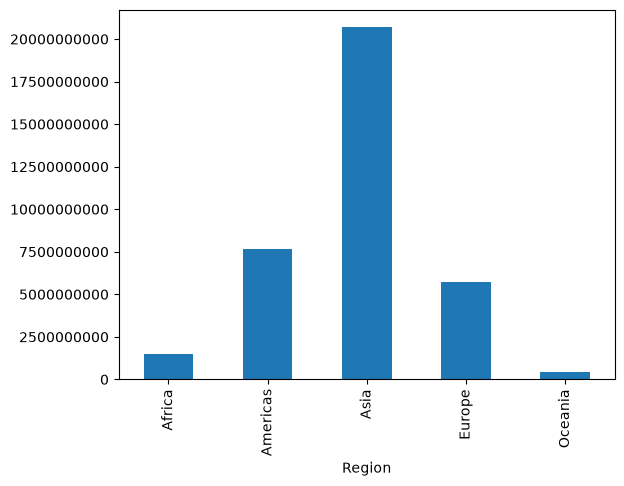

In [17]:
import matplotlib.pyplot as plt
columns_we_need = ["Full Name", "Region", "2022", "Population"]
emissions_2022_df = emissions_df[columns_we_need]
emissions_2022_df["Total Emissions"] = emissions_2022_df['2022'] * emissions_2022_df['Population']

emissions_2022_df = emissions_2022_df.rename(columns={"2022": "Emission per capita"})
pd.options.display.float_format = "{:.2f}".format
emissions_2022_df.groupby('Region')["Total Emissions"].sum().plot(kind="bar")

plt.ticklabel_format(style='plain', axis='y')